In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
ratings_dataframe = pd.read_csv('data/ratings.csv')
movies_dataframe = pd.read_csv('data/movies.csv')
number_users = ratings_dataframe['userId'].nunique()
number_movies = ratings_dataframe['movieId'].nunique()
number_ratings = len(ratings_dataframe)
all_possible_pairs = number_users * number_movies
sparsity = 1.0 - (number_ratings / all_possible_pairs)
print(f"Number of unique users:  {number_users}")
print(f"Number of unique movies: {number_movies}")
print(f"Total number of ratings: {number_ratings}")
print(f"Matrix Sparsity:         {sparsity:.4%} (fraction unrated)")
rating_matrix = ratings_dataframe.pivot_table(
    index='userId', 
    columns='movieId', 
    values='rating'
)

Number of unique users:  610
Number of unique movies: 9724
Total number of ratings: 100836
Matrix Sparsity:         98.3000% (fraction unrated)


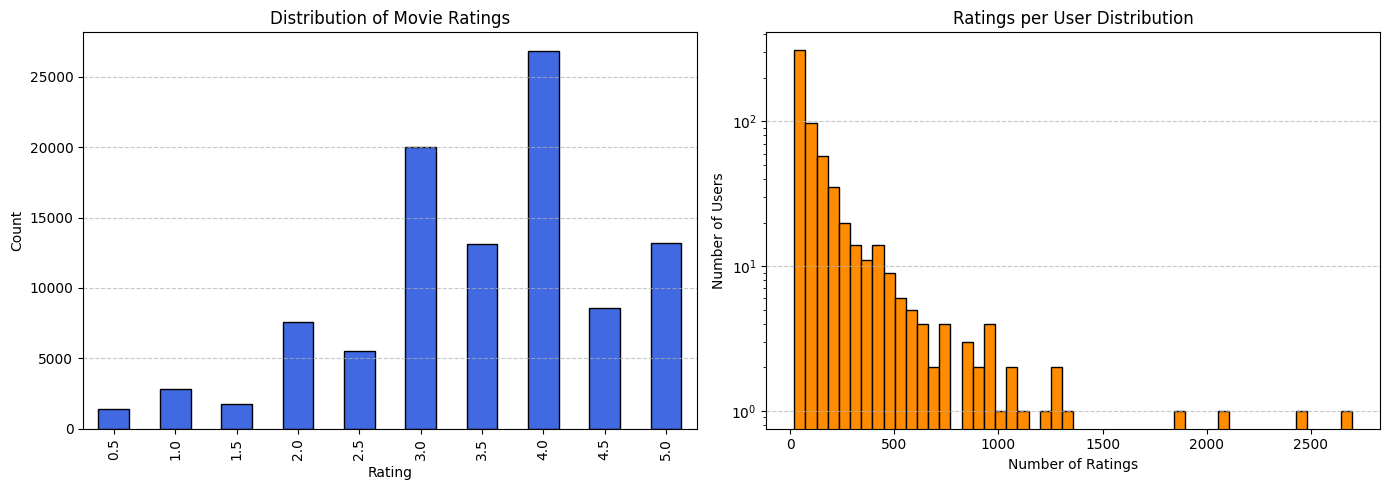

In [8]:
#ai genrated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of ratings
ratings_dataframe['rating'].value_counts().sort_index().plot(
    kind='bar', 
    ax=axes[0], 
    color='royalblue', 
    edgecolor='black'
)
axes[0].set_title('Distribution of Movie Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# (b) Distribution of ratings given per user
ratings_per_user = ratings_dataframe.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Ratings per User Distribution')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')
axes[1].set_yscale('log')  # Log scale highlights heavy-tail distribution
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
#end of ai

In [9]:
def get_co_rated(matrix: pd.DataFrame, a, b, axis: str = "index"):
    if axis == "index":
        vec_a = matrix.loc[a]
        vec_b = matrix.loc[b]
    elif axis == "columns":
        vec_a = matrix[a]
        vec_b = matrix[b]
    else:
        raise ValueError("axis must be either 'index' or 'columns'")
    common_mask = vec_a.notna() & vec_b.notna()
    return vec_a[common_mask].to_numpy(dtype=float), vec_b[common_mask].to_numpy(dtype=float)
    
def euclidean_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    
    diff = vec1 - vec2
    dist = np.sqrt(np.dot(diff, diff))
    return 1.0 / (1.0 + dist)

def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0
    
    return float(np.dot(vec1, vec2) / (norm1 * norm2))

def pearson_similarity(vec1: np.ndarray, vec2: np.ndarray):
    if len(vec1) < 2 or len(vec2) < 2:
        return None
    centered_1 = vec1 - np.mean(vec1)
    centered_2 = vec2 - np.mean(vec2)
    norm1 = np.linalg.norm(centered_1)
    norm2 = np.linalg.norm(centered_2)
    if norm1 == 0.0 or norm2 == 0.0:
        return 0.0
    return float(np.dot(centered_1, centered_2) / (norm1 * norm2))

In [10]:
#used for test will be removed
toy_a = np.array([5.0, 4.0, 5.0, 3.0])
toy_b = np.array([3.0, 2.0, 3.0, 1.0])

diff = toy_a - toy_b
raw_euclidean_dist = np.sqrt(np.dot(diff, diff))
euc_sim = euclidean_similarity(toy_a, toy_b)
cos_sim = cosine_similarity(toy_a, toy_b)
pea_sim = pearson_similarity(toy_a, toy_b)

print("--- Sanity Check: Section 3.2 Worked Example ---")
print(f"Raw Euclidean Distance : {raw_euclidean_dist:.4f}  (Expected: 4.0)")
print(f"Euclidean Similarity   : {euc_sim:.4f}            (1 / (1 + 4) = 0.2000)")
print(f"Cosine Similarity      : {cos_sim:.3f}             (Expected: ~0.987)")
print(f"Pearson Correlation    : {pea_sim:.1f}             (Expected: 1.0)")


--- Sanity Check: Section 3.2 Worked Example ---
Raw Euclidean Distance : 4.0000  (Expected: 4.0)
Euclidean Similarity   : 0.2000            (1 / (1 + 4) = 0.2000)
Cosine Similarity      : 0.987             (Expected: ~0.987)
Pearson Correlation    : 1.0             (Expected: 1.0)


THis part for User based collaborative filtering
Finding K nearest and predict Rating

In [11]:
def find_k_nearest_users(matrix, target_user, k, similarity_fn):
    similarities = []
    for user in matrix.index:

        # to skip comparing the target user with itself
        if user == target_user:
            continue

        # only movies rated by the 2 users
        vec1, vec2 = get_co_rated(matrix,target_user,user,axis="index")

        # skip fewer than 2 co-rated items
        if len(vec1) < 2:
            continue

        score = similarity_fn(vec1, vec2)
        similarities.append((user, score))

    # Highest similarity first (descending )
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]

def predict_rating_user_based(matrix,target_user,target_item,k,similarity_fn):
    
    neighbors = find_k_nearest_users(matrix,target_user,k,similarity_fn)

    numerator = 0.0
    denominator = 0.00

    for user, similarity in neighbors:

        # check this neighbor rated the target item
        rating = matrix.loc[user  , target_item]

        if pd.isna(rating):
            continue

        numerator += similarity * rating
        denominator += abs(similarity)

    if denominator == 0:
        return None

    return numerator / denominator

THis part for Item based collaborative filtering
Finding K nearest and predict Rating for Items

In [12]:
def find_k_nearest_items(matrix, target_item, k, similarity_fn):
    similarities = []

    for item in matrix.columns:

        # skip comparing the target item to itself
        if item == target_item:
            continue

        #only users who rated the 2 items
        vec1, vec2 = get_co_rated(matrix,target_item,item,axis="columns")

        # Skip if fewer than 2 users rated the both items
        if len(vec1) <2:
            continue

        score = similarity_fn(vec1, vec2)

        similarities.append((item, score))

    # Highest similarity first (descending )
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:k]

def predict_rating_item_based(matrix,target_user,target_item,k,similarity_fn):
    neighbors = find_k_nearest_items(matrix,target_item,k,similarity_fn)

    numerator = 0.00
    denominator = 0.0

    for item , similarity in neighbors:

        # make sure targeted user rated this similar item
        rating = matrix.loc[target_user, item]

        if pd.isna(rating):
            continue

        numerator +=similarity * rating
        denominator +=abs(similarity)

    if denominator == 0:
        return None
    
    return numerator / denominator

The steps were exactly the same as used for user-based functions 
the algorithm was comparing corated values and calculating similarity , taking k nearest neighbors , and making predictions
In item based filtering instead of comparing rows (users) we compare columns (items) and then use the ratings of the target user for similar items to make a prediction

In [13]:
# just for testing and will be removed
test_matrix = pd.DataFrame(
    {
        101: [5.0, 5.0, 1.0, 4.0],
        102: [4.0, 4.0, 2.0, 5.0],
        103: [1.0, 1.0, 5.0, 2.0],
        104: [np.nan, 4.0, 1.0, 3.0],
    },
    index=[1, 2, 3, 4],
)

user_neighbors = find_k_nearest_users(
    test_matrix, target_user=1, k=2, similarity_fn=euclidean_similarity
)
item_neighbors = find_k_nearest_items(
    test_matrix, target_item=104, k=2, similarity_fn=euclidean_similarity
)

user_prediction = predict_rating_user_based(
    test_matrix, target_user=1, target_item=104,
    k=2, similarity_fn=euclidean_similarity
)
item_prediction = predict_rating_item_based(
    test_matrix, target_user=1, target_item=104,
    k=2, similarity_fn=euclidean_similarity
)

assert all(user != 1 for user, _ in user_neighbors)
assert all(item != 104 for item, _ in item_neighbors)
assert user_prediction is not None
assert item_prediction is not None
assert 1 <= user_prediction <= 5
assert 1 <= item_prediction <= 5

print("User neighbors:", user_neighbors)
print("Item neighbors:", item_neighbors)
print("User-based prediction:", user_prediction)
print("Item-based prediction:", item_prediction)
# ya rab 2ftker 2ms7o

User neighbors: [(2, np.float64(1.0)), (4, np.float64(0.36602540378443865))]
Item neighbors: [(101, np.float64(0.4142135623730951)), (102, np.float64(0.3090169943749474))]
User-based prediction: 3.7320508075688776
Item-based prediction: 4.572726855230756
